In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import numpy as np
from dataclasses import asdict

from mjlab.envs import ManagerBasedRlEnv
from mjlab.rl import MjlabOnPolicyRunner, RslRlVecEnvWrapper
from mjlab.tasks.registry import (
    load_env_cfg,
    load_rl_cfg,
    load_runner_cls,
)
from mjlab.utils.torch import configure_torch_backends

TASK_ID = "Mjlab-Velocity-Flat-MicroDuck"
ckpt_file = "/home/boyu/projects/microduck_rl/logs/rsl_rl/velocity/2026-10-04_22-14-54_velocity/model_4999.pt"

configure_torch_backends()
device = "cuda:0" if torch.cuda.is_available() else "cpu"

[mdp] Patches 1-2 active: NaN-safe reward/advantage
[mdp] Patch 4 active: ONNX export filters passive_* joints
[mdp] Patch 5 active: MICRODUCK_WARM_START=1 restarts curricula after checkpoint load


In [2]:
env_cfg = load_env_cfg(TASK_ID, play=True)
env_cfg.scene.num_envs = 1
# Play mode pushes every 0.5-1.0 s. That is for robustness viewing, not a
# nominal tracking trace.
env_cfg.events.pop("push_robot", None)

agent_cfg = load_rl_cfg(TASK_ID)

runner_cls = load_runner_cls(TASK_ID) or MjlabOnPolicyRunner

# Freeze twist sampling. runner.load() restores common_step_counter from the
# checkpoint, and the standing curriculum would then set rel_standing_envs to
# its final value. _update_command zeros vel_command_b every step on those
# envs, so a later write of the requested vx does not reach the policy.
for name in ("standing_envs", "head_pose_range", "body_pose_range"):
    env_cfg.curriculum.pop(name, None)

twist_cfg = env_cfg.commands["twist"]
twist_cfg.resampling_time_range = (1000.0, 1000.0)
twist_cfg.ranges.lin_vel_y = (0.0, 0.0)
twist_cfg.ranges.ang_vel_z = (0.0, 0.0)
for attr in (
    "rel_standing_envs",
    "rel_heading_envs",
    "rel_turn_in_place_envs",
    "rel_world_envs",
    "rel_forward_envs",
    "init_velocity_prob",
):
    if hasattr(twist_cfg, attr):
        setattr(twist_cfg, attr, 0.0)

for name in ("head_pose", "body_pose"):
    pose_cfg = env_cfg.commands[name]
    pose_cfg.resampling_time_range = (1000.0, 1000.0)
    pose_cfg.ranges = tuple((0.0, 0.0) for _ in pose_cfg.ranges)

env = ManagerBasedRlEnv(
    cfg=env_cfg,
    device=device,
)

env = RslRlVecEnvWrapper(
    env=env,
    clip_actions=agent_cfg.clip_actions,
)

resume_path = Path(ckpt_file).resolve()
print(f"checkpoint = {resume_path}")

runner = runner_cls(
    env,
    asdict(agent_cfg),
    device=device,
)

runner.load(
    str(resume_path),
    load_cfg={"actor": True},
    strict=True,
    map_location=device,
)

policy = runner.get_inference_policy(device=device)

base_env = env.unwrapped
robot = base_env.scene["robot"]

dt = float(base_env.step_dt)

/home/boyu/projects/microduck_rl/.venv/lib/python3.12/site-packages/mjlab/entity/entity.py:149: UserWarning: Actuator config matched 14 joint(s) but the same expressions also match 7 site(s): imu, left_foot, head_camera, tof, head_imu, mouth_tip, right_foot. Add a separate config with transmission_type=TransmissionType.SITE if those should be actuated too.
  self._add_actuators()


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 5000 Blackwell" (47 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/boyu/.cache/warp/1.12.0
Warp DeprecationWarning: The symbol `warp.context.runtime` will soon be removed from the public API. It can still be accessed from `warp._src.context.runtime` but might be changed or removed without notice.
Module mujoco_warp._src.smooth 95a0b8b load on device 'cuda:0' took 2.02 ms  (cached)
Module mujoco_warp._src.collision_driver 88f7770 load on device 'cuda:0' took 0.25 ms  (cached)
Module _nxn_broadphase__locals__kernel_e73b1315 e73b131 load on device 'cuda:0' took 0.25 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_079dfa94 079dfa9 load on device 'cuda:0' took 2.00 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_b282a07a b282a07 load on device 'cuda:0' took 0.45 ms  (cached)
Module mujoco_warp._src.constraint 27c5

In [3]:
cmd_term = base_env.command_manager.get_term("twist")
command = base_env.command_manager.get_command("twist")

def set_twist(vx, vy=0.0, yaw=0.0):
    """Write a twist command and keep _update_command from replacing it.

    Standing, heading, and world-frame flags are re-applied inside every
    env.step. Pin the ranges too, so an auto-reset resamples this same command.
    """
    cmd_term.cfg.ranges.lin_vel_x = (float(vx), float(vx))
    cmd_term.cfg.ranges.lin_vel_y = (float(vy), float(vy))
    cmd_term.cfg.ranges.ang_vel_z = (float(yaw), float(yaw))
    cmd_term.cfg.rel_standing_envs = 0.0
    cmd_term.is_standing_env[:] = False
    cmd_term.is_heading_env[:] = False
    cmd_term.is_world_env[:] = False
    cmd_term.is_forward_env[:] = False
    cmd_term.vel_command_b[:, 0] = vx
    cmd_term.vel_command_b[:, 1] = vy
    cmd_term.vel_command_b[:, 2] = yaw
    cmd_term.vel_command_w[:] = cmd_term.vel_command_b


In [6]:
# (duration in seconds, target vx)
schedule = [
    (2.0, 0.0),   # 0.0s - 2.0s: settle / stand still (0.0 m/s)
    (4.0, 0.2),   # 2.0s - 6.0s: walk slow (0.2 m/s)
    (4.0, 0.5),   # 6.0s - 10.0s: walk medium (0.5 m/s)
    (4.0, 0.8),   # 10.0s - 14.0s: walk fast (0.8 m/s)
    (4.0, 0.0),   # 14.0s - 18.0s: stop (0.0 m/s)
]

# Start from a full episode. A second run of this cell would otherwise
# continue the previous 18 s and hit the 20 s timeout immediately.
env.reset()
vx_commands = []
vx_actual = []
for duration, vx_cmd in schedule:
    set_twist(vx_cmd)
    # Refresh after the write. The obs captured before set_twist still
    # carries the previous command, so the first action would ignore vx_cmd.
    obs = env.get_observations()
    n_segment_steps = int(round(duration / dt))
    for _ in range(n_segment_steps):
        with torch.no_grad():
            actions = policy(obs)
        obs, _, dones, _ = env.step(actions)
        if bool(dones[0].item()):
            # This step already auto-reset. Do not record the reset state,
            # and put the segment command back before the next action.
            print(f"episode ended at t={len(vx_commands) * dt:.3f} s")
            vx_commands.append(np.nan)
            vx_actual.append(np.nan)
            set_twist(vx_cmd)
            obs = env.get_observations()
            continue
        commanded = float(command[0, 0].item())
        if abs(commanded - vx_cmd) > 1e-4:
            raise RuntimeError(
                f"twist vx overwritten: requested {vx_cmd}, command is {commanded}"
            )
        vx_commands.append(commanded)
        vx_actual.append(robot.data.root_link_lin_vel_b[0, 0].item())
vx_commands = np.array(vx_commands)
vx_actual = np.array(vx_actual)


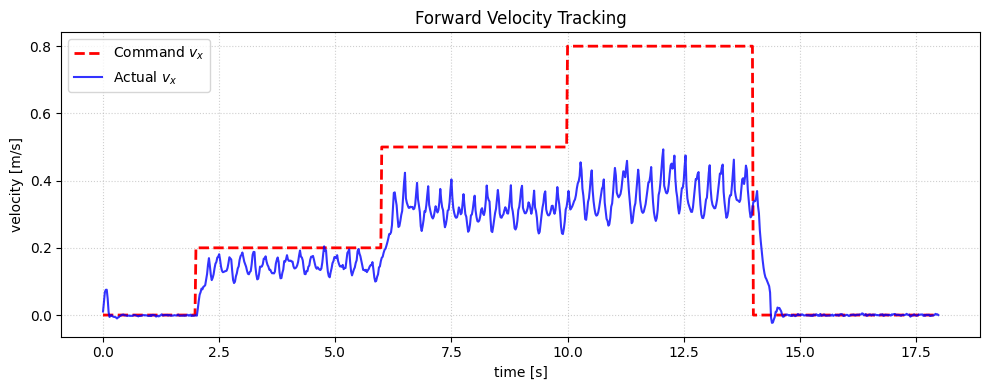

In [7]:
time = np.arange(len(vx_commands)) * dt
fig, axes = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

axes.plot(time, vx_commands, "r--", linewidth=2.0, label="Command $v_x$")
axes.plot(time, vx_actual, "b-", alpha=0.8, label="Actual $v_x$")
axes.set_xlabel("time [s]")
axes.set_ylabel("velocity [m/s]")
axes.set_title("Forward Velocity Tracking")
axes.legend(loc="upper left")
axes.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [8]:
# ---- Velocity-gait relation: sweep vx, log foot contacts ----
vx_sweep = [0.2, 0.4, 0.6, 0.8]
SEG_T, SETTLE_T = 8.0, 0.0   # seconds per command / discarded transient

contact_sensor = base_env.scene.sensors["feet_ground_contact"]
found_names = [
    slot.primary_name
    for slot in contact_sensor._slots
    if slot.field_name == "found"
]
if found_names[:2] != ["left_foot_collision", "right_foot_collision"]:
    raise RuntimeError(f"unexpected foot contact order: {found_names}")

site_ids, site_names = robot.find_sites(
    ("left_foot", "right_foot"),
    preserve_order=True,
)

def mean_or_nan(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0 or not np.any(np.isfinite(x)):
        return float("nan")
    return float(np.mean(x))

def rising_edge_indices(x):
    x = np.asarray(x, dtype=bool)
    if x.size < 2:
        return np.empty(0, dtype=int)
    return np.flatnonzero((~x[:-1]) & x[1:]) + 1

def step_lengths_at_touchdown(swing_pos, stance_pos, td_idx):
    """Horizontal distance between the feet at each touchdown of swing_pos."""
    if td_idx.size == 0:
        return np.empty(0)
    delta = swing_pos[td_idx, :2] - stance_pos[td_idx, :2]
    return np.linalg.norm(delta, axis=-1)

def run_segment(vx_cmd):
    set_twist(vx_cmd)
    obs_ = env.get_observations()
    t, lc, rc, vx = [], [], [], []
    left_foot_pos_w, right_foot_pos_w = [], []
    n_steps = int(round(SEG_T / dt))
    for step in range(n_steps):
        with torch.no_grad():
            a = policy(obs_)
        obs_, _, d, _ = env.step(a)
        if bool(d[0].item()):
            print(f"  vx={vx_cmd}: episode ended at t={step * dt:.2f}s")
            break
        commanded = float(command[0, 0].item())
        if abs(commanded - vx_cmd) > 1e-4:
            raise RuntimeError(
                f"twist vx overwritten: requested {vx_cmd}, command is {commanded}"
            )
        foot_pos_w = robot.data.site_pos_w[0, site_ids].detach().cpu().numpy()
        left_foot_pos_w.append(foot_pos_w[0].copy())
        right_foot_pos_w.append(foot_pos_w[1].copy())
        f = contact_sensor.data.found[0, :2].detach().cpu().numpy() > 0
        t.append(step * dt)
        lc.append(bool(f[0]))
        rc.append(bool(f[1]))
        vx.append(robot.data.root_link_lin_vel_b[0, 0].item())
    k = int(round(SETTLE_T / dt))
    if len(t) <= k:
        print(f"  vx={vx_cmd}: no samples after the {SETTLE_T:.0f}s settle")
        return None
    sl = slice(k, None)
    return {
        "t": np.asarray(t[sl]),
        "left_contact": np.asarray(lc[sl], dtype=bool),
        "right_contact": np.asarray(rc[sl], dtype=bool),
        "vx": np.asarray(vx[sl]),
        "left_foot_pos_w": np.asarray(left_foot_pos_w[sl]),
        "right_foot_pos_w": np.asarray(right_foot_pos_w[sl]),
    }

sweeps = []
for v in vx_sweep:
    env.reset()
    out = run_segment(v)
    sweeps.append(out)
    if out is None:
        print(f"vx={v:.1f}  failed")
        continue
    left_td = rising_edge_indices(out["left_contact"])
    right_td = rising_edge_indices(out["right_contact"])
    left_period = mean_or_nan(np.diff(out["t"][left_td]))
    right_period = mean_or_nan(np.diff(out["t"][right_td]))
    left_freq = 1.0 / left_period if left_period > 0.0 else float("nan")
    right_freq = 1.0 / right_period if right_period > 0.0 else float("nan")
    # Foot positions are trimmed with the contact window, and each touchdown
    # is paired with the other foot at that same step.
    steps = np.concatenate([
        step_lengths_at_touchdown(out["left_foot_pos_w"], out["right_foot_pos_w"], left_td),
        step_lengths_at_touchdown(out["right_foot_pos_w"], out["left_foot_pos_w"], right_td),
    ])
    step_len = mean_or_nan(steps)
    print(
        f"vx={v:.1f}  actual={out['vx'].mean():.3f} m/s  "
        f"stride={left_freq:.2f}/{right_freq:.2f} Hz (L/R)  "
        f"step={step_len:.3f} m"
    )



vx=0.2  actual=0.112 m/s  stride=1.97/2.04 Hz (L/R)  step=0.101 m
vx=0.4  actual=0.237 m/s  stride=1.99/2.06 Hz (L/R)  step=0.112 m
vx=0.6  actual=0.361 m/s  stride=2.23/2.17 Hz (L/R)  step=0.128 m
vx=0.8  actual=0.274 m/s  stride=1.91/1.98 Hz (L/R)  step=0.127 m


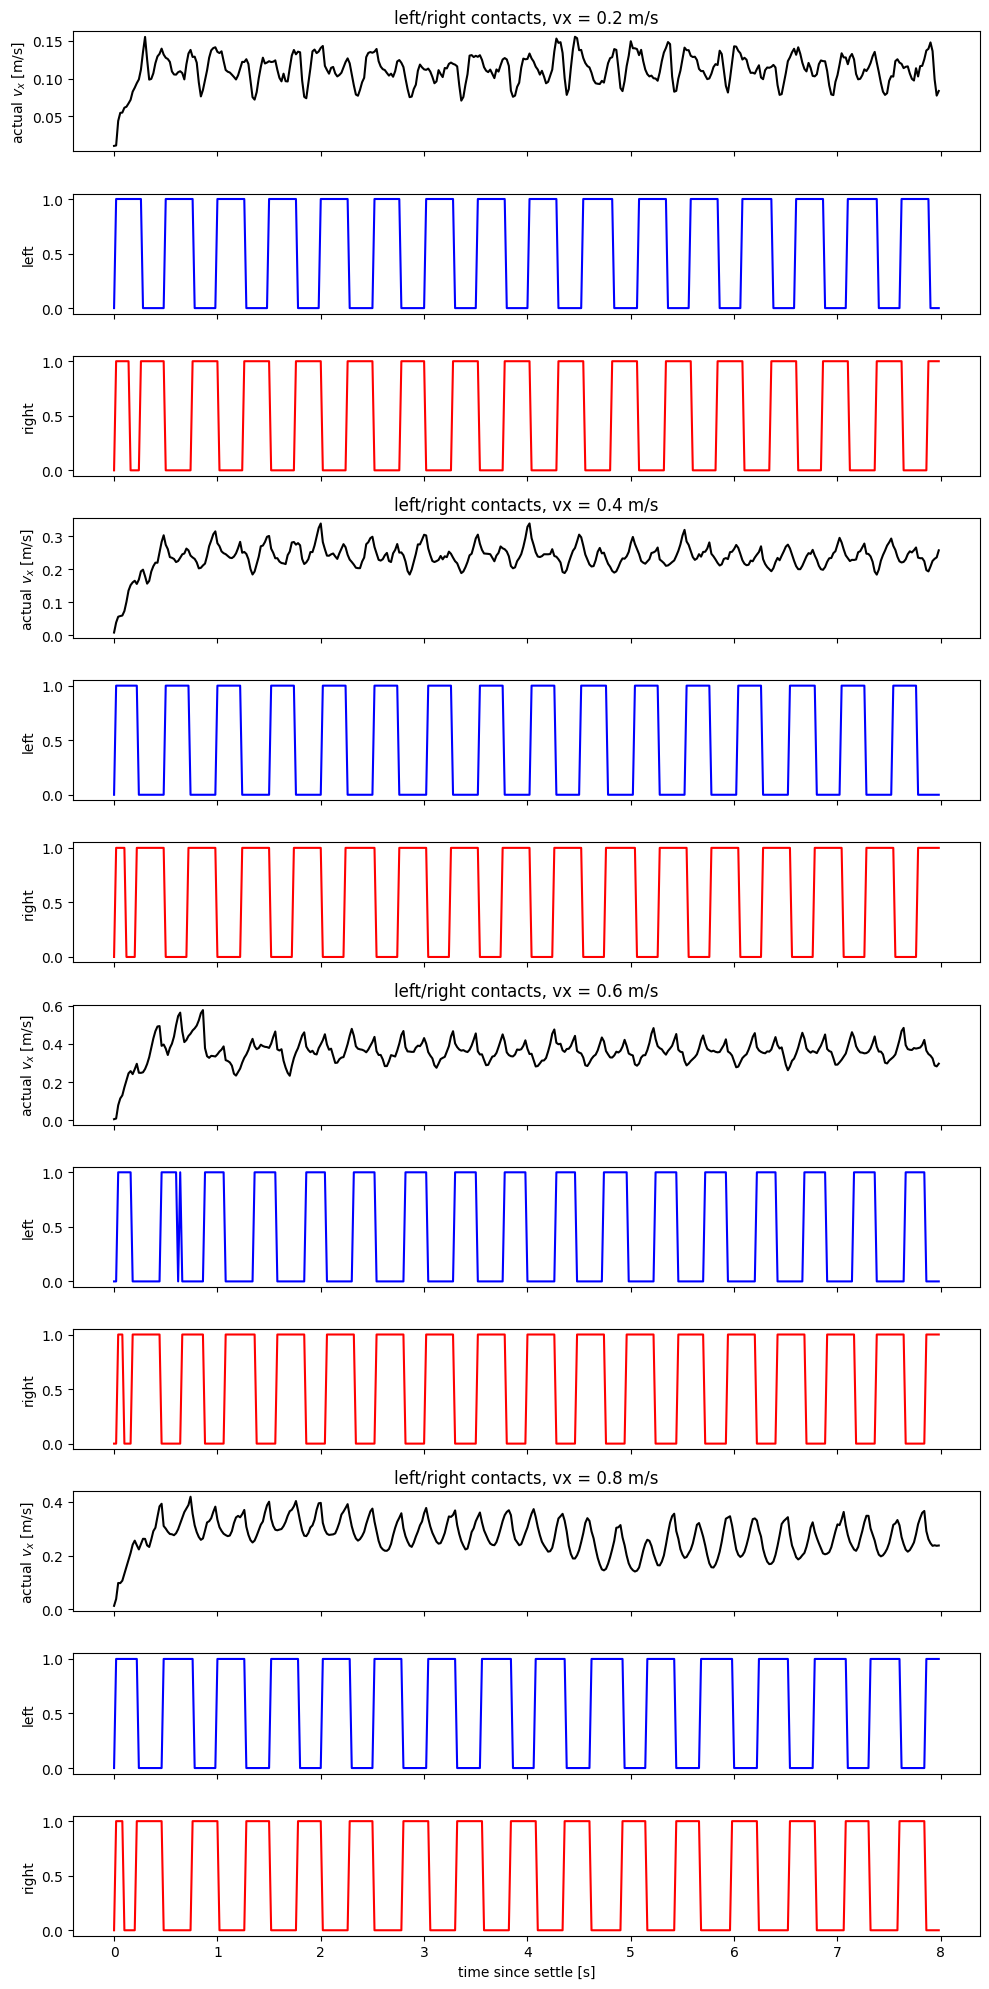

In [9]:
# left-right contact curve
fig, axes = plt.subplots(
    len(vx_sweep) * 3,
    1,
    figsize=(10, 20),
    sharex=True,
)

for i, vx in enumerate(vx_sweep):
    ax_v = axes[i * 3]
    ax_l = axes[i * 3 + 1]
    ax_r = axes[i * 3 + 2]
    ax_v.set_title(f"left/right contacts, vx = {vx} m/s")
    ax_v.set_ylabel("actual $v_x$ [m/s]")
    ax_l.set_ylabel("left")
    ax_r.set_ylabel("right")
    ax_l.set_ylim(-0.05, 1.05)
    ax_r.set_ylim(-0.05, 1.05)
    out = sweeps[i]
    if out is None:
        ax_v.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax_v.transAxes)
        continue
    t = out["t"] - out["t"][0]
    ax_v.plot(t, out["vx"], color="black")
    ax_l.plot(t, out["left_contact"].astype(float), color="blue")
    ax_r.plot(t, out["right_contact"].astype(float), color="red")

axes[-1].set_xlabel("time since settle [s]")
fig.tight_layout()
plt.show()
